# Baselines for LSST Classification

- **B1**: Catch22 + RF (see `Baseline_first_model.ipynb`) — ~60% accuracy
- **B2**: MultiROCKET (aeon, no pre-training)
- **B3**: 1D-CNN from scratch (PyTorch)

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.data_loader import load_lsst_for_sklearn, stratified_train_val_split, SEED
from src.baselines import train_multirocket, train_cnn
from src.metrics import evaluate, plot_confusion_matrix, results_table

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [2]:
data = load_lsst_for_sklearn()
X_train, X_test = data["X_train"], data["X_test"]
y_train, y_test = data["y_train"], data["y_test"]
class_names = data["class_names"]
class_weights = data["class_weights"]
n_classes = data["n_classes"]

print(f"Train: {X_train.shape}, Test: {X_test.shape}, Classes: {n_classes}")

Train: (2459, 6, 36), Test: (2466, 6, 36), Classes: 14


## B2: MultiROCKET

In [3]:
rocket = train_multirocket(X_train, y_train)
y_pred_rocket = rocket.predict(X_test)
metrics_rocket = evaluate(y_test, y_pred_rocket, class_names, "MultiROCKET")

=== MultiROCKET ===
Accuracy:    0.6375
Weighted F1: 0.6039
Macro F1:    0.4615
              precision    recall  f1-score   support

          15       0.63      0.45      0.53       124
          16       0.93      0.93      0.93       270
          42       0.43      0.43      0.43       382
          52       0.00      0.00      0.00        63
          53       1.00      0.57      0.73         7
           6       0.57      0.11      0.19        35
          62       0.25      0.15      0.19       153
          64       0.00      0.00      0.00        24
          65       0.72      0.85      0.78       313
          67       0.21      0.04      0.07        68
          88       0.94      0.84      0.89       121
          90       0.60      0.81      0.69       777
          92       0.92      0.88      0.90        77
          95       0.50      0.08      0.13        52

    accuracy                           0.64      2466
   macro avg       0.55      0.44      0.46      2466


/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

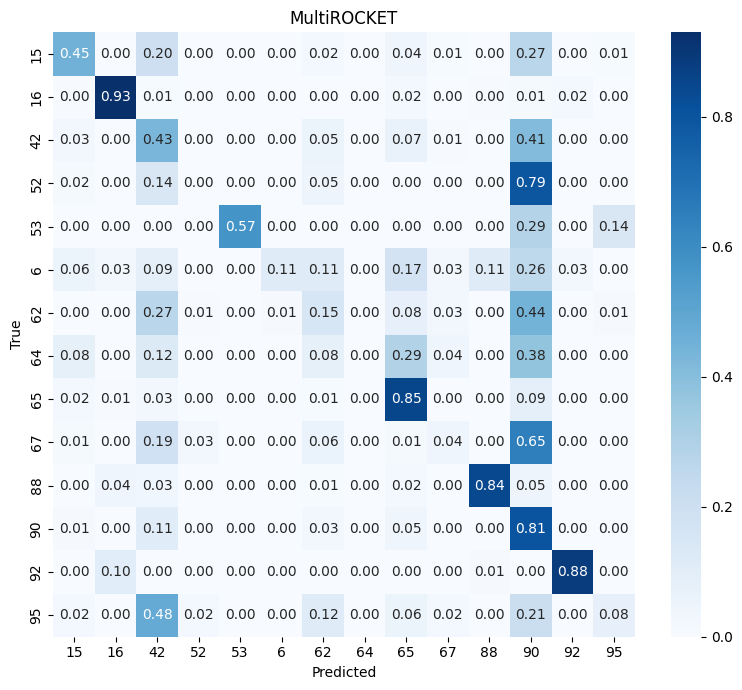

In [4]:
fig, ax = plot_confusion_matrix(y_test, y_pred_rocket, class_names, "MultiROCKET")
plt.show()

## B3: 1D-CNN from scratch

In [5]:
# Stratified train/val split for early stopping
X_tr, X_val, y_tr, y_val = stratified_train_val_split(X_train, y_train)
print(f"Train: {X_tr.shape}, Val: {X_val.shape}")

Train: (1967, 6, 36), Val: (492, 6, 36)


In [6]:
cnn_model, cnn_history = train_cnn(
    X_tr, y_tr, X_val, y_val, class_weights,
    n_channels=6, seq_len=36, n_classes=n_classes,
    epochs=100, lr=1e-3, batch_size=128, patience=15,
    device=device,
)

Epoch 10/100 — train_loss=1.9373  val_loss=2.1282  val_acc=0.2012
Epoch 20/100 — train_loss=1.5642  val_loss=1.7652  val_acc=0.2073


Epoch 30/100 — train_loss=1.3874  val_loss=1.6767  val_acc=0.2907
Epoch 40/100 — train_loss=1.3507  val_loss=1.7612  val_acc=0.2764
Early stopping at epoch 42


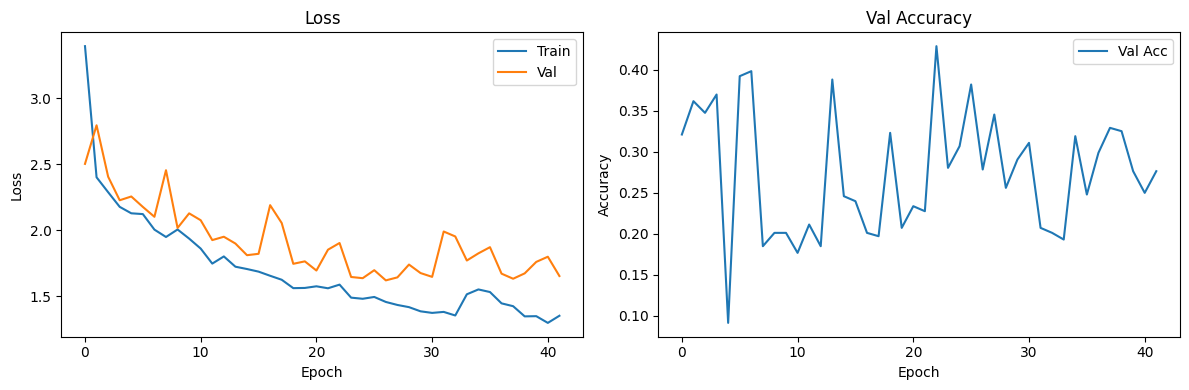

In [7]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(cnn_history["train_loss"], label="Train")
ax1.plot(cnn_history["val_loss"], label="Val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend(); ax1.set_title("Loss")
ax2.plot(cnn_history["val_acc"], label="Val Acc")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.legend(); ax2.set_title("Val Accuracy")
plt.tight_layout(); plt.show()

In [8]:
# Evaluate CNN on test set
cnn_model.eval()
X_test_t = torch.tensor(X_test, dtype=torch.float32, device=device)
with torch.no_grad():
    y_pred_cnn = cnn_model(X_test_t).argmax(1).cpu().numpy()

metrics_cnn = evaluate(y_test, y_pred_cnn, class_names, "1D-CNN")

=== 1D-CNN ===
Accuracy:    0.2737
Weighted F1: 0.3014
Macro F1:    0.3743
              precision    recall  f1-score   support

          15       0.43      0.65      0.52       124
          16       0.73      0.49      0.59       270
          42       0.50      0.03      0.05       382
          52       0.04      0.54      0.07        63
          53       0.88      1.00      0.93         7
           6       0.50      0.31      0.39        35
          62       0.25      0.10      0.15       153
          64       0.04      0.17      0.06        24
          65       0.41      0.14      0.21       313
          67       0.09      0.40      0.14        68
          88       0.80      0.68      0.73       121
          90       0.52      0.18      0.27       777
          92       0.80      0.86      0.82        77
          95       0.25      0.38      0.31        52

    accuracy                           0.27      2466
   macro avg       0.44      0.42      0.37      2466
weigh

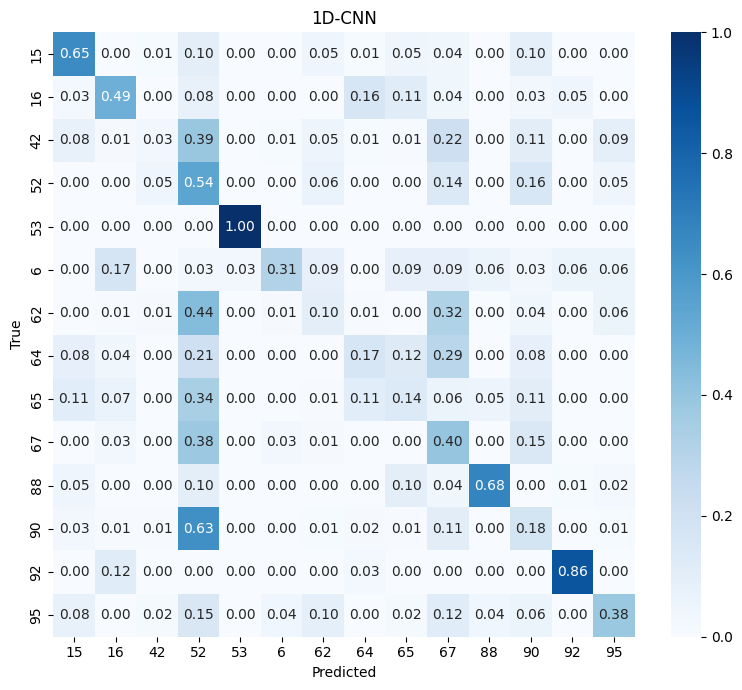

In [9]:
fig, ax = plot_confusion_matrix(y_test, y_pred_cnn, class_names, "1D-CNN")
plt.show()

## Summary

In [10]:
all_results = {
    "Catch22 + RF (B1)": dict(accuracy=0.60, weighted_f1=0.54, macro_f1=0.31),  # from notebook 1
    "MultiROCKET (B2)": metrics_rocket,
    "1D-CNN (B3)": metrics_cnn,
}
results_table(all_results)

Model                               Acc     W-F1     M-F1
---------------------------------------------------------
Catch22 + RF (B1)                0.6000   0.5400   0.3100
MultiROCKET (B2)                 0.6375   0.6039   0.4615
1D-CNN (B3)                      0.2737   0.3014   0.3743
